                  mean        std  count
state                                   
baseline    898.751773  40.576654    282
meditation  908.583333  44.816684     84
stress      953.796053  28.067879    152
ANOVA p = 5.1589494345782756e-39
Kruskal p = 1.2727406256051156e-37


/tmp/ipykernel_519/1094602932.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


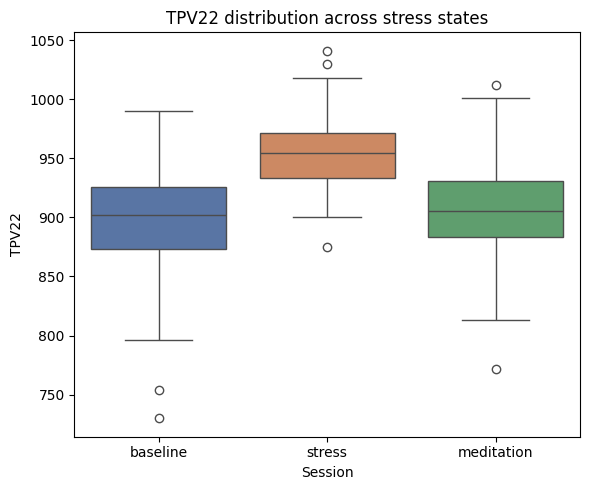

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

# load
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BP/TPV-csv/noQC.csv")

# 상태 이름 정리
df["state"] = df["label_major"].map({
    1: "baseline",
    2: "stress",
    4: "meditation"
})

# TPV22만 사용
data = df[["subject", "state", "TPV22"]].dropna()

# -------------------------
# Mean ± STD 계산
# -------------------------
summary = data.groupby("state")["TPV22"].agg(["mean","std","count"])
print(summary)

# -------------------------
# p-value (ANOVA)
# -------------------------
b = data[data.state=="baseline"]["TPV22"]
s = data[data.state=="stress"]["TPV22"]
m = data[data.state=="meditation"]["TPV22"]

anova = f_oneway(b,s,m)
kruskal_test = kruskal(b,s,m)

print("ANOVA p =", anova.pvalue)
print("Kruskal p =", kruskal_test.pvalue)

# -------------------------
# Figure
# -------------------------
plt.figure(figsize=(6,5))

sns.boxplot(
    x="state",
    y="TPV22",
    data=data,
    palette=["#4C72B0","#DD8452","#55A868"]
)

plt.xlabel("Session")
plt.ylabel("TPV22")
plt.title("TPV22 distribution across stress states")

plt.tight_layout()
plt.show()